In [2]:
import pandas as pd
import json
import numpy as np
import requests
from tqdm.auto import tqdm
from config import URL, TOKEN


import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [5]:
headers = {
    "Authorization": f"Bearer {TOKEN}"
}

itemCount = np.inf
data = {"entries": []}

offset = 0
steps = 1000

progress = None

while len(data["entries"]) < itemCount:

    response = requests.get(
        f"{URL}person/caregiver/query?filter=section.eingestellt-am:answerDateTime.timeUtc:gte:20170101000000,section.eingestellt-am:answerDateTime.timeUtc:lt:20260101000000&limit={steps}&skip={offset}",
        headers=headers,
        verify=False
    )

    if response.status_code == 200:
        responseData = response.json()

        entries = responseData["entries"]

        # Total becomes known after first request
        if progress is None:
            itemCount = responseData["pagingInfo"]["itemCount"]

            progress = tqdm(
                total=itemCount,
                desc="Downloading caregivers",
                unit="entries"                
            )

        data["entries"].extend(entries)

        # Advance by actual number received
        progress.update(len(entries))

        offset += steps

    else:
        print(response.json())
        break

if progress is not None:
    progress.close()

In [6]:
exceptions = [
	"metadata",
	"locality",
	"postalcode",
	"contactoptions",
	"personFullName",
	"personFullNameNoTitle",
	"tenantid",
	"persontype",
	"adresse",
	"mailAddressing",
	"socialInsuranceNumber",
	"comments",
	"givenName",
	"familyName",
	"primaryEmailAddress",
	'addresses',
	'primaryPhoneNumber',
	'address',
	'residentialAddress',
	'address',
	'geoLocation',
	'billingAddress',
	'serviceAddress',
	'legalAddress',
	'businessAddress',
	'emailAddresses',
	'phoneNumbers',
	'personFullNameNoTitle',
	'personFullName',
	'mailAddressing',
	'postalAddress',
	'contractualAddressing',
	'caatsDateOfBirth',
	'gender',
	'locations',
	'bankDetails',
	'personStatus',
	"chapterId",
	"language",
	"ordinal",
	"sectionId",
	"academicTitlePrefix",
	"personNr",
	"content",
	"consecutiveNumber",
	'Klient:innen_Empfohlen_Ja',
	'Klient:innen_Erstrkontakt_erfassen_Ja',
	'Klient:innen_Bew_Ein_Ja',
	'abrech-akonto',
	'abrech-buerge-hinterlegt',
	'pers-visite-keine',
	'medizinische-delegation-hochgeladen',
	'medizinische-delegation-nicht-notwendig',
	'Klient:innen_Medizinische_Delegation_Ja',
	'pflegerische-delegation-hochgeladen',
	'pflegerische-delegation-nicht-notwendig',
	'Klient:innen_Pflegerische_Delegation_JA',
	"admin-beruf",
	'pflegevisite-letzte-date',
	'pflegevisite-letzte-dgkp',
	'pflegerisch-person',
	'erstkontakt-bemerkung',
	"admin-kooperationspartner",
	'birthName',
'confessionId',
'confession',
'nationalityId',
'placeOfBirth',
'paymentBlockReason',
'chamberOfCommerceMembershipNr',
'avatarFileId',
'empfohlen-von-category',
'visibilityConditionId',
'deutschkennt-bew-von',
'Kinder_Nein',
'covid-1',
'covid-2',
'covid-3',
"cpvod-1-mit",
"covid-1-wo",
"cpvod-2-mit",
"covid-2-wo",
"cpvod-3-mit",
"covid-3-wo",
"gewerbeschein_nr",

"PFSystem",
'keine-kurse',
'agentur-zuletzt',
'BE_PERSONALAUSWEIS_NR',
'BE_PERSONALAUSWEIS_BEHOERDE',
'BE_PERSONALAUSWEIS_GUELTIG_AB',
'BE_PERSONALAUSWEIS'
]

exceptions = [x.lower() for x in exceptions]

In [7]:
def extractStatement(statement):
    field = {}
    if statement["statementId"].lower() in exceptions:
        return field

    match statement["answerScheme"]:
        case 1:
            field[statement["statementId"]] = statement["answerValue"]["displayText"]
        case 2:
            #do nothing
            field = {}
        case 3:
            field[statement["statementId"]] = statement["answerYesno"] == 2
        case 4:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False

        case 5:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False
        case 8:
            if "answerDateTime" in statement.keys():
                if "userLocalTime" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["userLocalTime"]
                elif "timeUtc" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["timeUtc"]
        case _:
            print(f'Found statement: {statement["answerScheme"]} - {statement["statementId"]} -  {statement}')


    return field
        

def returnEntry(entry):
    keys = entry.keys()
    finalFields = {}
    if "statementId" in keys:
        finalFields = finalFields | extractStatement(entry)
    else:
        for key in keys:
            
            if key.lower() in exceptions:
                continue
            
            typing = type(entry[key]).__name__
            match typing:
                case "str":
                    finalFields[key] = entry[key]
                    
                case "int":
                    finalFields[key] = entry[key]

                case "bool":
                    finalFields[key] = entry[key]

                case "float":
                    finalFields[key] = entry[key]
                    
                case "dict":
                    if "displayText" in entry[key].keys():
                        finalFields[key] = entry[key]["displayText"]
                        continue
                    else:
                        finalFields = finalFields | returnEntry(entry[key])
                    
                case "list":
                    for item in entry[key]:
                        if type(item).__name__ == "dict":
                            finalFields = finalFields | returnEntry(item)
                        

                case _:
                    print(typing)


    
    return finalFields

In [8]:

totalData = []

if data["entries"] is not None:
    for entry in data["entries"]:
        test = returnEntry(entry)
        totalData.append(test)
        
df = pd.DataFrame(totalData)
df

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,eingestellt-am,...,isPaymentBlocked,allgemeine-erfahrung-ausland-dauer,covid-1-wann,covid-2-wann,erfahrung-krankenhaus-abteilung,allgemeine-taetigkeiten-ausland,grund-unpassend,weitere_ausbildungen,fachspezifische-ausbildung-welche,BE_REISEPASS
0,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,Sonstiges,False,2.019071e+13,20190903020000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,Blagoiescu,False,2.025013e+13,20250206010000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,00411252-62ff-bc52-5ab0-5fbfd476b2a2,Team Rumänien,19710127,Rumänien,Verwitwet,Blagoiescu,False,2.025101e+13,20251016020000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F,004afdff-fff7-9d87-63ae-7273409908bb,ZZ_Palaloga rum.,19680328,Österreich,Geschieden,ZZ_Cotrans,False,2.020013e+13,20200213010000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F,0061dab5-0194-a1a8-5aba-d718f21e2ff7,ZZ_PML Übernahme,19660517,Slowakei,Verwitwet,Selbstfahrer,False,2.022100e+13,20221001020000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,F,ffddabef-72ea-967e-dc01-c9edbb211fb7,Team Rumänien,19700303,Rumänien,Ledig,Master Express,False,2.023042e+13,20230425020000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7367,F,ffdde431-8a90-7beb-4330-a7956fb650aa,ZZ_Palaloga rum.,19800428,Rumänien,Ledig,Blagoiescu,False,2.020081e+13,20200818020000,...,NaN,NaN,2.021122e+13,2.021122e+13,NaN,NaN,NaN,NaN,NaN,NaN
7368,F,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,Direktbewerbung,19640207,Rumänien,Verheiratet,Master Express,False,2.018101e+13,20181023020000,...,NaN,NaN,2.021051e+13,2.021051e+13,NaN,NaN,NaN,NaN,NaN,NaN
7369,F,ffe47fdd-10cb-ff7b-5190-85f5fff12bd0,Team Ungarn,19681129,Ungarn,Ledig,Selbstfahrer,False,2.019101e+13,20191112010000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
for col in df.columns:
    non_null = df[col].dropna()

    if len(non_null) > 0 and non_null.isin([True, False]).all():
        df[col] = df[col].fillna(False).astype(bool)

bool_cols = df.select_dtypes(include=["bool", "boolean"]).columns

df[bool_cols] = df[bool_cols].fillna(False)


df = df.replace(r'^\s*$', np.nan, regex=True)

df.to_csv("caregiverRaw.csv", index=False, sep=";")

df

C:\Users\npozdena\AppData\Local\Temp\ipykernel_25836\4131787707.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
C:\Users\npozdena\AppData\Local\Temp\ipykernel_25836\4131787707.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
C:\Users\npozdena\AppData\Local\Temp\ipykernel_25836\4131787707.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) inste

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,eingestellt-am,...,isPaymentBlocked,allgemeine-erfahrung-ausland-dauer,covid-1-wann,covid-2-wann,erfahrung-krankenhaus-abteilung,allgemeine-taetigkeiten-ausland,grund-unpassend,weitere_ausbildungen,fachspezifische-ausbildung-welche,BE_REISEPASS
0,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,Sonstiges,False,2.019071e+13,20190903020000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,Blagoiescu,False,2.025013e+13,20250206010000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,F,00411252-62ff-bc52-5ab0-5fbfd476b2a2,Team Rumänien,19710127,Rumänien,Verwitwet,Blagoiescu,False,2.025101e+13,20251016020000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,F,004afdff-fff7-9d87-63ae-7273409908bb,ZZ_Palaloga rum.,19680328,Österreich,Geschieden,ZZ_Cotrans,False,2.020013e+13,20200213010000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,F,0061dab5-0194-a1a8-5aba-d718f21e2ff7,ZZ_PML Übernahme,19660517,Slowakei,Verwitwet,Selbstfahrer,False,2.022100e+13,20221001020000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7366,F,ffddabef-72ea-967e-dc01-c9edbb211fb7,Team Rumänien,19700303,Rumänien,Ledig,Master Express,False,2.023042e+13,20230425020000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7367,F,ffdde431-8a90-7beb-4330-a7956fb650aa,ZZ_Palaloga rum.,19800428,Rumänien,Ledig,Blagoiescu,False,2.020081e+13,20200818020000,...,False,NaN,2.021122e+13,2.021122e+13,NaN,NaN,NaN,NaN,NaN,False
7368,F,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,Direktbewerbung,19640207,Rumänien,Verheiratet,Master Express,False,2.018101e+13,20181023020000,...,False,NaN,2.021051e+13,2.021051e+13,NaN,NaN,NaN,NaN,NaN,False
7369,F,ffe47fdd-10cb-ff7b-5190-85f5fff12bd0,Team Ungarn,19681129,Ungarn,Ledig,Selbstfahrer,False,2.019101e+13,20191112010000,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [42]:
df.isna().sum()[df.isna().sum() > 0]

maritalStatus                         1923
preferredTransport                     306
bew-am                                1047
einstellvor                           6535
empfohlen-von                         1835
start-geplant                         1408
ausgesch-am                           1831
aussch-grund                          1865
BE_PERSONALAUSWEIS_NR                 1852
BE_PERSONALAUSWEIS_BEHOERDE           2457
BE_PERSONALAUSWEIS_GUELTIG_AB         2285
pers-dat-sprach-mutt                   101
pers-dat-sprach-weitere               3762
pers-dat-sprach-deuselbst             1502
deutschkennt-akt                      1156
deutschkennt-pass                     1171
pers-dat-kinder-anz                   3872
pers-dat-kinder-alt                   6269
pers-koerper-groesse                   690
pers-koerper-gewicht                   680
pflegestatus-paket                     617
ausbildungsstaette                    2718
raucher-zig-taegl-ca                   215
hobbies    

In [43]:
protected_cols = ["eingestellt-am", "id", "ausgesch-am"]

# All normal feature columns
feature_cols = df.columns.drop(protected_cols)

# Keep only feature columns with <= 10% missing
keep_features = feature_cols[
    df[feature_cols].isna().mean() <= 0.10
]

# Keep protected columns + surviving features
df = df[protected_cols + keep_features.tolist()]

# Drop rows with missing values in:
# - eingestellt-am
# - id
# - any remaining feature
#
# ausgesch-am is intentionally excluded
required_cols = ["eingestellt-am", "id"] + keep_features.tolist()

df = df.dropna(subset=required_cols)

In [44]:
df

,eingestellt-am,id,ausgesch-am,genderId,orgRef,dateOfBirth,nationality,preferredTransport,Betreuer:innen_Bew_Ein_Ja,istangest,...,PFKompEmotional,PFKompAllgemein,arrivalSelfOrganized,departureSelfOrganized,arrivalNoBilling,departureNoBilling,Gewerbe_ruhend_Ja,Betreuer:innen_Austritt_Ja,e-zigarette,isPaymentBlocked
0,20190903020000,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,2.025042e+13,F,Direktbewerbung,19950804,Rumänien,Sonstiges,False,True,...,0,0,False,False,False,False,False,False,False,False
2,20251016020000,00411252-62ff-bc52-5ab0-5fbfd476b2a2,2.025111e+13,F,Team Rumänien,19710127,Rumänien,Blagoiescu,False,True,...,0.5,0.5,False,False,False,False,False,False,False,False
3,20200213010000,004afdff-fff7-9d87-63ae-7273409908bb,2.020031e+13,F,ZZ_Palaloga rum.,19680328,Österreich,ZZ_Cotrans,False,True,...,0,0,False,False,False,False,False,False,False,False
4,20221001020000,0061dab5-0194-a1a8-5aba-d718f21e2ff7,2.023031e+13,F,ZZ_PML Übernahme,19660517,Slowakei,Selbstfahrer,False,True,...,0,0,True,True,True,True,False,False,False,False
5,20211103010000,006e3125-8abb-6cee-fcc0-e17c52ce84b4,2.021120e+13,F,Team Rumänien,19770821,Rumänien,Master Express,False,True,...,1.5,1.5,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,20231228010000,ffdbb7d5-a94f-d177-4495-069e1692c3e4,NaN,F,Team Rumänien,19720820,Rumänien,Blagoiescu,False,True,...,0.928571428571429,0.928571428571429,False,False,False,False,False,False,False,False
7366,20230425020000,ffddabef-72ea-967e-dc01-c9edbb211fb7,2.026033e+13,F,Team Rumänien,19700303,Rumänien,Master Express,False,True,...,1,0.88,False,False,False,False,False,False,False,False
7367,20200818020000,ffdde431-8a90-7beb-4330-a7956fb650aa,NaN,F,ZZ_Palaloga rum.,19800428,Rumänien,Blagoiescu,False,True,...,1.33,1.22,False,False,False,False,False,False,False,False
7368,20181023020000,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,2.025111e+13,F,Direktbewerbung,19640207,Rumänien,Master Express,False,True,...,1.22,1.26,False,False,False,False,False,False,False,False


In [45]:
min_unique = 2
max_unique = len(df) * 0.9


n_unique = df.nunique()

cols_to_drop = n_unique[
    (n_unique < min_unique) | (n_unique > max_unique)
].index

cols_to_drop = [col for col in cols_to_drop if col not in ["id", "ausgesch-am", "eingestellt-am"]]

df = df.drop(columns=cols_to_drop)

df

,eingestellt-am,id,ausgesch-am,genderId,orgRef,dateOfBirth,nationality,preferredTransport,istangest,macht-stundenpak,...,PFKompSprache,PFKompHaushalt,PFKompBetreuung,PFKompEmotional,PFKompAllgemein,arrivalSelfOrganized,departureSelfOrganized,arrivalNoBilling,departureNoBilling,isPaymentBlocked
0,20190903020000,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,2.025042e+13,F,Direktbewerbung,19950804,Rumänien,Sonstiges,True,False,...,0,0,0,0,0,False,False,False,False,False
2,20251016020000,00411252-62ff-bc52-5ab0-5fbfd476b2a2,2.025111e+13,F,Team Rumänien,19710127,Rumänien,Blagoiescu,True,True,...,1,1,0.5,0.5,0.5,False,False,False,False,False
3,20200213010000,004afdff-fff7-9d87-63ae-7273409908bb,2.020031e+13,F,ZZ_Palaloga rum.,19680328,Österreich,ZZ_Cotrans,True,True,...,0,0,0,0,0,False,False,False,False,False
4,20221001020000,0061dab5-0194-a1a8-5aba-d718f21e2ff7,2.023031e+13,F,ZZ_PML Übernahme,19660517,Slowakei,Selbstfahrer,True,True,...,0,0,0,0,0,True,True,True,True,False
5,20211103010000,006e3125-8abb-6cee-fcc0-e17c52ce84b4,2.021120e+13,F,Team Rumänien,19770821,Rumänien,Master Express,True,True,...,3.5,1,1,1.5,1.5,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,20231228010000,ffdbb7d5-a94f-d177-4495-069e1692c3e4,NaN,F,Team Rumänien,19720820,Rumänien,Blagoiescu,True,True,...,2.21428571428571,0.857142857142857,0.857142857142857,0.928571428571429,0.928571428571429,False,False,False,False,False
7366,20230425020000,ffddabef-72ea-967e-dc01-c9edbb211fb7,2.026033e+13,F,Team Rumänien,19700303,Rumänien,Master Express,True,True,...,3.25,0.75,0.88,1,0.88,False,False,False,False,False
7367,20200818020000,ffdde431-8a90-7beb-4330-a7956fb650aa,NaN,F,ZZ_Palaloga rum.,19800428,Rumänien,Blagoiescu,True,True,...,1.56,1.11,0.78,1.33,1.22,False,False,False,False,False
7368,20181023020000,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,2.025111e+13,F,Direktbewerbung,19640207,Rumänien,Master Express,True,False,...,2,1.17,1.17,1.22,1.26,False,False,False,False,False


In [50]:
if "genderId" in df.columns:
    df = pd.get_dummies(df, columns=["genderId"], prefix="gender", drop_first=True)
if "orgRef" in df.columns:
    df = pd.get_dummies(df, columns=["orgRef"], prefix="org", drop_first=True)
if "nationality" in df.columns:
    df = pd.get_dummies(df, columns=["nationality"], prefix="nationality", drop_first=True)
if "preferredTransport" in df.columns:
    df = pd.get_dummies(df, columns=["preferredTransport"], prefix="preferredTransport", drop_first=True)
if "pers-dat-sprach-mutt" in df.columns:
    df = pd.get_dummies(df, columns=["pers-dat-sprach-mutt"], prefix="mutSprach", drop_first=True)
if "admin-betr-gsber" in df.columns:
    df = pd.get_dummies(df, columns=["admin-betr-gsber"], prefix="geschBereich", drop_first=True)
if "pflegestatus-paket" in df.columns:
    df = pd.get_dummies(df, columns=["pflegestatus-paket"], prefix="pflegestatus", drop_first=True)

if "PFKompSprache" in df.columns:
	df["PFKompSprache"] = df["PFKompSprache"].astype(float).round(0).astype(int)
if "PFKompHaushalt" in df.columns:
	df["PFKompHaushalt"] = df["PFKompHaushalt"].astype(float).round(0).astype(int)
if "PFKompBetreuung" in df.columns:
	df["PFKompBetreuung"] = df["PFKompBetreuung"].astype(float).round(0).astype(int)
if "PFKompEmotional" in df.columns:
	df["PFKompEmotional"] = df["PFKompEmotional"].astype(float).round(0).astype(int)
if "PFKompAllgemein" in df.columns:
	df["PFKompAllgemein"] = df["PFKompAllgemein"].astype(float).round(0).astype(int)
if "eingestellt-am" in df.columns:
	df["eingestellt-am"] = df["eingestellt-am"].astype(str).str[:8].astype(float)
if "ausgesch-am" in df.columns:
	df["ausgesch-am"] = df["ausgesch-am"].astype(str).str[:8].astype(float)
if "pers-koerper-gewicht" in df.columns:
	df["pers-koerper-gewicht"] = df["pers-koerper-gewicht"].astype(float).round(0).astype(int)
if "pers-koerper-groesse" in df.columns:
	df["pers-koerper-groesse"] = df["pers-koerper-groesse"].astype(float).round(0).astype(int)

In [51]:



cols = df.columns.drop(
    ["id", "ausgesch-am", "eingestellt-am"]
)

converted = df[cols].apply(pd.to_numeric, errors="coerce")

# Columns containing problematic values
problem_cols = cols[
    converted.isna().any() & df[cols].notna().any()
]

print(problem_cols)

if len(problem_cols) ==0:
    numeric = df[cols].apply(
            pd.to_numeric,
            errors="coerce"
    )

        # Keep only rows where all columns converted successfully
    df = df[numeric.notna().all(axis=1)].copy()

        # Convert to int
    df[cols] = df[cols].astype(int)

Index([], dtype='object')


In [52]:
df

,eingestellt-am,id,ausgesch-am,dateOfBirth,istangest,macht-stundenpak,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,BE_PERSONALAUSWEIS,...,pflegestatus_CD Perle Plus,pflegestatus_Demenzbetreuung,pflegestatus_Diplomierte Fachkraft,pflegestatus_Klassik,pflegestatus_Palliativbegleitung,pflegestatus_Premium,pflegestatus_ZZ_Pflege leicht,pflegestatus_ZZ_Pflegerin,pflegestatus_ZZ_Springerin,pflegestatus_ZZ_Standard Plus
0,20190903.0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,20250423.0,19950804,1,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,20251016.0,00411252-62ff-bc52-5ab0-5fbfd476b2a2,20251113.0,19710127,1,1,1,1,1,0,...,0,0,0,1,0,0,0,0,0,0
3,20200213.0,004afdff-fff7-9d87-63ae-7273409908bb,20200310.0,19680328,1,1,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0
4,20221001.0,0061dab5-0194-a1a8-5aba-d718f21e2ff7,20230307.0,19660517,1,1,1,1,1,0,...,0,0,0,0,0,1,0,0,0,0
5,20211103.0,006e3125-8abb-6cee-fcc0-e17c52ce84b4,20211201.0,19770821,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,20231228.0,ffdbb7d5-a94f-d177-4495-069e1692c3e4,NaN,19720820,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
7366,20230425.0,ffddabef-72ea-967e-dc01-c9edbb211fb7,20260331.0,19700303,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7367,20200818.0,ffdde431-8a90-7beb-4330-a7956fb650aa,NaN,19800428,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
7368,20181023.0,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,20251106.0,19640207,1,0,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [53]:
correlation_matrix = df.drop(columns=["id", "ausgesch-am", "eingestellt-am"]).corr()

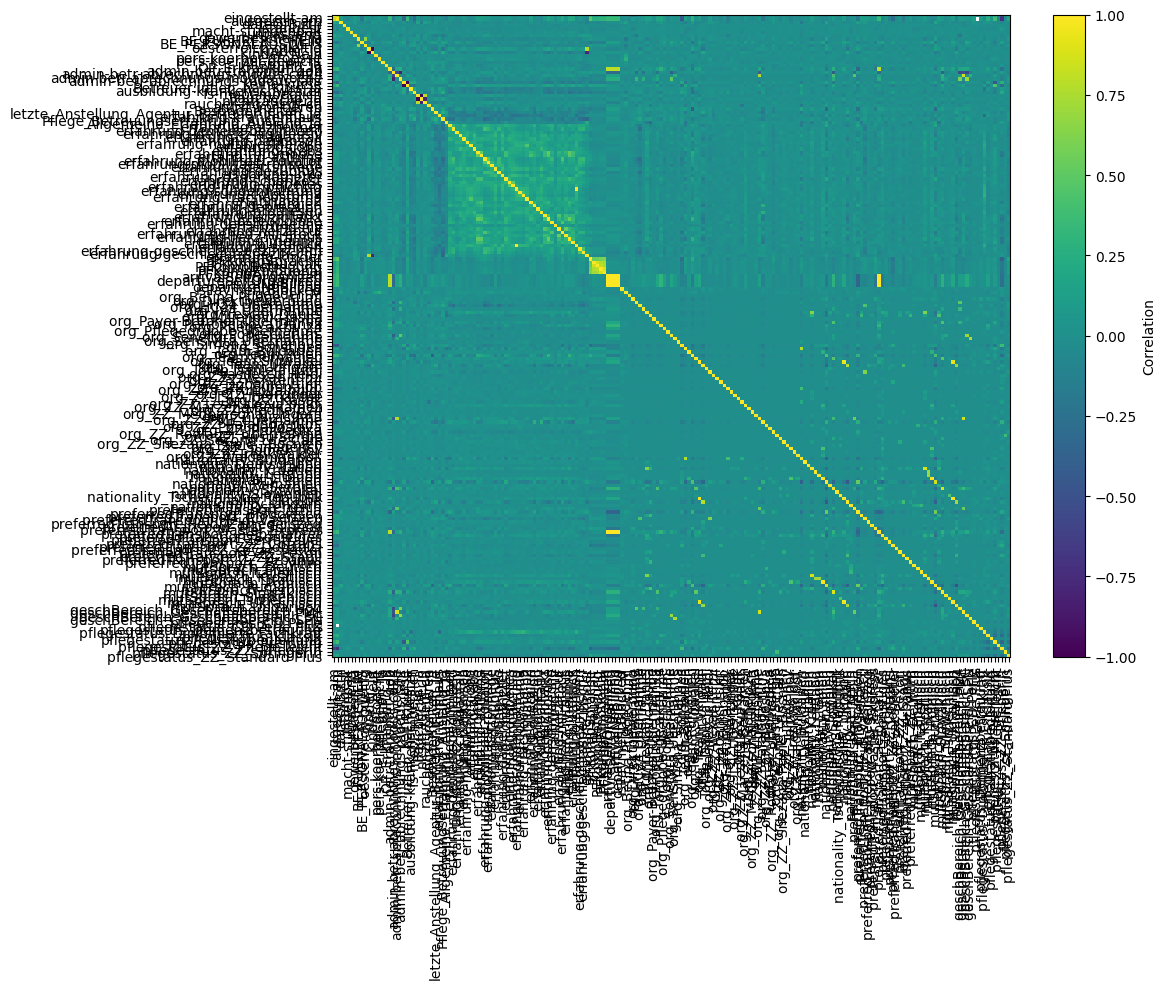

In [54]:
import matplotlib.pyplot as plt

corr = df.drop(columns=["id"]).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [55]:
def remove_correlated_features(df, threshold=0.8, exclude=["id"]):

    result = df.copy()
    dropped = []

    while True:

        features = result.drop(
            columns=exclude,
            errors="ignore"
        )

        corr = features.corr().abs()

        # Remove diagonal
        np.fill_diagonal(corr.values, 0)

        # Find strongest remaining correlation
        max_corr = corr.max().max()

        if max_corr <= threshold:
            break

        # Find the pair
        var1, var2 = corr.stack().idxmax()

        # Mean absolute correlation with all other variables
        score1 = corr.loc[var1].mean()
        score2 = corr.loc[var2].mean()

        # Drop the more redundant variable
        if score1 > score2:
            drop = var1
        else:
            drop = var2

        dropped.append({
            "dropped": drop,
            "var1": var1,
            "var2": var2,
            "pair_corr": max_corr,
            "score_var1": score1,
            "score_var2": score2
        })

        result = result.drop(columns=drop)

    return result, pd.DataFrame(dropped)

In [56]:
df_reduced, dropped = remove_correlated_features(
    df,
    threshold=0.7,
    exclude=["id", "ausgesch-am", "eingestellt-am"]
)

print(dropped)

                               dropped                                var1  \
0           Betreuer:innen_hat_Kurs_Ja                         keine-kurse   
1                     erfahrung-sonden             erfahrung-sondennahrung   
2               departureSelfOrganized                arrivalSelfOrganized   
3                     arrivalNoBilling                arrivalSelfOrganized   
4                   departureNoBilling                arrivalSelfOrganized   
5      preferredTransport_Selbstfahrer                arrivalSelfOrganized   
6                          Kinder_Nein                           Kinder_Ja   
7                       nichtraucherin                       Raucher:in_Ja   
8                    nationality_Polen                   nationality_Polen   
9                  nationality_Ukraine                 nationality_Ukraine   
10                mutSprach_Ukrainisch                    org_Team Ukraine   
11                nationality_Slowakei                nationalit

In [57]:
df_reduced

,eingestellt-am,id,ausgesch-am,dateOfBirth,istangest,macht-stundenpak,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,BE_PERSONALAUSWEIS,...,pflegestatus_CD Perle Plus,pflegestatus_Demenzbetreuung,pflegestatus_Diplomierte Fachkraft,pflegestatus_Klassik,pflegestatus_Palliativbegleitung,pflegestatus_Premium,pflegestatus_ZZ_Pflege leicht,pflegestatus_ZZ_Pflegerin,pflegestatus_ZZ_Springerin,pflegestatus_ZZ_Standard Plus
0,20190903.0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,20250423.0,19950804,1,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,20251016.0,00411252-62ff-bc52-5ab0-5fbfd476b2a2,20251113.0,19710127,1,1,1,1,1,0,...,0,0,0,1,0,0,0,0,0,0
3,20200213.0,004afdff-fff7-9d87-63ae-7273409908bb,20200310.0,19680328,1,1,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0
4,20221001.0,0061dab5-0194-a1a8-5aba-d718f21e2ff7,20230307.0,19660517,1,1,1,1,1,0,...,0,0,0,0,0,1,0,0,0,0
5,20211103.0,006e3125-8abb-6cee-fcc0-e17c52ce84b4,20211201.0,19770821,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7365,20231228.0,ffdbb7d5-a94f-d177-4495-069e1692c3e4,NaN,19720820,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
7366,20230425.0,ffddabef-72ea-967e-dc01-c9edbb211fb7,20260331.0,19700303,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7367,20200818.0,ffdde431-8a90-7beb-4330-a7956fb650aa,NaN,19800428,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
7368,20181023.0,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,20251106.0,19640207,1,0,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0


In [58]:
df_reduced.to_csv("caregivers.csv", sep=";", index=False)